# Initialize Spark and importing a dataset from the virtual campus

In [0]:
from pyspark.sql import SparkSession


spark = SparkSession.builder.appName("Step3 wordcounter").getOrCreate()

#loading the data
wrd = spark.read.table("workspace.default.annex_1_aplication")


print(f"Total rows: {wrd.count()}")
display(wrd.limit(10))

Total rows: 300


value
Speech
Processing
Assistants
Assistants
Vision
Predictive
Vision
Assistants
Vision
Predictive


---------------------------------------------------------------------------
ImportError                               Traceback (most recent call last)
File <command-8609456391242054>, line 1
----> 1 from pyspark import Sparksession

ImportError: cannot import name 'Sparksession' from 'pyspark' (/databricks/python/lib/python3.12/site-packages/pyspark/__init__.py)

#Performing ETL tasks (Extract,Transform, Load) using PySpark 

In [0]:
from pyspark.sql.functions import col, initcap, explode, split, trim, substring, when

# Remove rows with null values
wrd_clean = wrd.filter(col("value").isNotNull())

# Convert the first letter of each word to uppercase
wrd_clean = wrd_clean.withColumn("value", initcap(col("value")))

# Identify if the first letter of each word is a vowel or consonant and remove empty strings
wrd_clean = wrd_clean.withColumn(
    "first_letter_type",
    when(
        substring(col("value"), 1, 1).isin("A", "E", "I", "O", "U"),
        "vowel"
    ).otherwise("consonant")
)
wrd_clean = wrd_clean.filter(trim(col("value")) != "")

# Display the result
display(wrd_clean.limit(10))
print(f"Total rows: {wrd_clean.count()}")

value,first_letter_type
Speech,consonant
Processing,consonant
Assistants,vowel
Assistants,vowel
Vision,consonant
Predictive,consonant
Vision,consonant
Assistants,vowel
Vision,consonant
Predictive,consonant


Total rows: 296


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8609456391242129>, line 21
     18 wrd_clean = wrd_clean.filter(trim(col("first_letter_type")) != "")
     20 # Display the result
---> 21 display(wrd_clean.limit(10))
     22 print(f"Total rows: {wrd_clean.count()}")

File /databricks/python_shell/lib/dbruntime/display.py:136, in Display.display(self, input, *args, **kwargs)
    134     pass
    135 elif self._cf_helper is not None and isinstance(input, ConnectDataFrame):
--> 136     self.display_connect_table(input, **kwargs)
    137 elif isinstance(input, ConnectDataFrame):
    138     if input.isStreaming:

File /databricks/python_shell/lib/dbruntime/display.py:96, in Display.display_connect_table(self, df, **kwargs)
     91 except Exception as e:
     92     raise type(
     93         e
     94     )("IPython shell encountered an error or was missing data, please res

In [0]:
from pyspark.sql.functions import substring, col

# Extract the first letter from each word
wrd_first_letter = wrd_clean.withColumn("first_letter", substring(col("value"), 1, 1))

# Display the result
display(wrd_first_letter.limit(20))

value,first_letter_type,first_letter
Speech,consonant,S
Processing,consonant,P
Assistants,vowel,A
Assistants,vowel,A
Vision,consonant,V
Predictive,consonant,P
Vision,consonant,V
Assistants,vowel,A
Vision,consonant,V
Predictive,consonant,P


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-8609456391242128>, line 7
      4 wrd_first_letter = wrd_clean.withColumn("first_letter", substring(col("words"), 1, 1))
      6 # Display the result
----> 7 display(wrd_first_letter.limit(20))

File /databricks/python_shell/lib/dbruntime/display.py:136, in Display.display(self, input, *args, **kwargs)
    134     pass
    135 elif self._cf_helper is not None and isinstance(input, ConnectDataFrame):
--> 136     self.display_connect_table(input, **kwargs)
    137 elif isinstance(input, ConnectDataFrame):
    138     if input.isStreaming:

File /databricks/python_shell/lib/dbruntime/display.py:96, in Display.display_connect_table(self, df, **kwargs)
     91 except Exception as e:
     92     raise type(
     93         e
     94     )("IPython shell encountered an error or was missing data, please restart the notebook or con

#Running  SQL  queries  using  Spark  SQL to  analyze  textual  or numeric data 

In [0]:
wrd_clean.createOrReplaceTempView("wrd_clean_view")

# Count words starting with a vowel
result = spark.sql("""
    SELECT first_letter_type, COUNT(*) AS count
    FROM wrd_clean_view
    GROUP BY first_letter_type
""")

display(result)

first_letter_type,count
consonant,232
vowel,64


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4840430629239551>, line 1
----> 1 wrd_clean.createOrReplaceTempView("wrd_clean_view")
      3 # Example SQL query: Count occurrences of each word
      4 word_count_df = spark.sql("""
      5     SELECT words, COUNT(*) AS word_count
      6     FROM wrd_clean_view
      7     GROUP BY words
      8     ORDER BY word_count DESC
      9 """)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2115, in DataFrame.createOrReplaceTempView(self, name)
   2111 def createOrReplaceTempView(self, name: str) -> None:
   2112     command = plan.CreateView(
   2113         child=self._plan, name=name, is_global=False, replace=True
   2114     ).command(session=self._session.client)
-> 2115     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2116     self._execution_

In [0]:
from pyspark.sql.functions import substring, col

# Count occurrences of each initial letter
initial_letter_count = wrd_clean.withColumn("first_letter", substring(col("value"), 1, 1)) \
    .groupBy("first_letter") \
    .count() \
    .orderBy("count", ascending=False)

display(initial_letter_count)

first_letter,count
R,81
V,66
A,64
P,62
S,18
L,5


In [0]:
from pyspark.sql.functions import length

# Count occurrences of each word length
word_length_count = wrd_clean.withColumn("word_length", length(col("value"))) \
    .groupBy("word_length") \
    .count() \
    .orderBy("word_length")

display(word_length_count)

word_length,count
6,84
8,66
10,126
11,4
14,16


In [0]:
from pyspark.sql.functions import col

# Count occurrences of each word
word_count = wrd_clean.groupBy(col("value")).count().orderBy("count", ascending=False)

display(word_count)

value,count
Vision,66
Assistants,62
Robotics,61
Predictive,54
Speech,18
Recommendation,16
Processing,8
Learning,5
Recognition,4
Automation,2


#Generating a visualization or summary output 

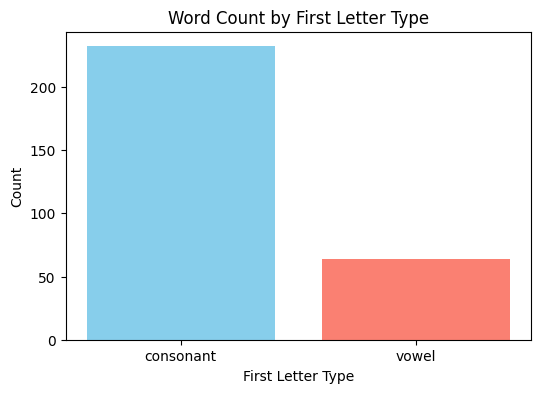

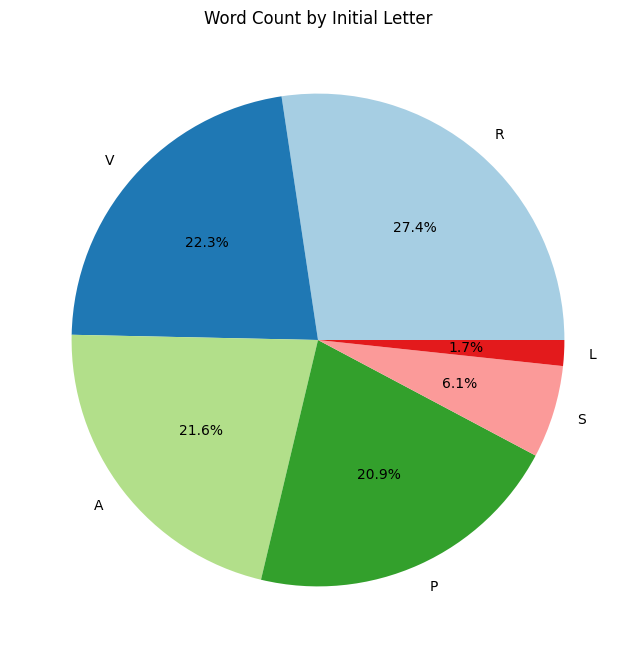

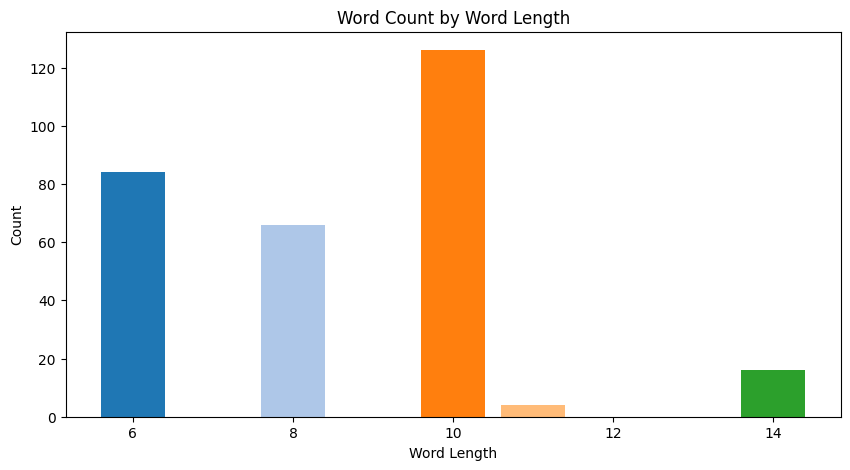

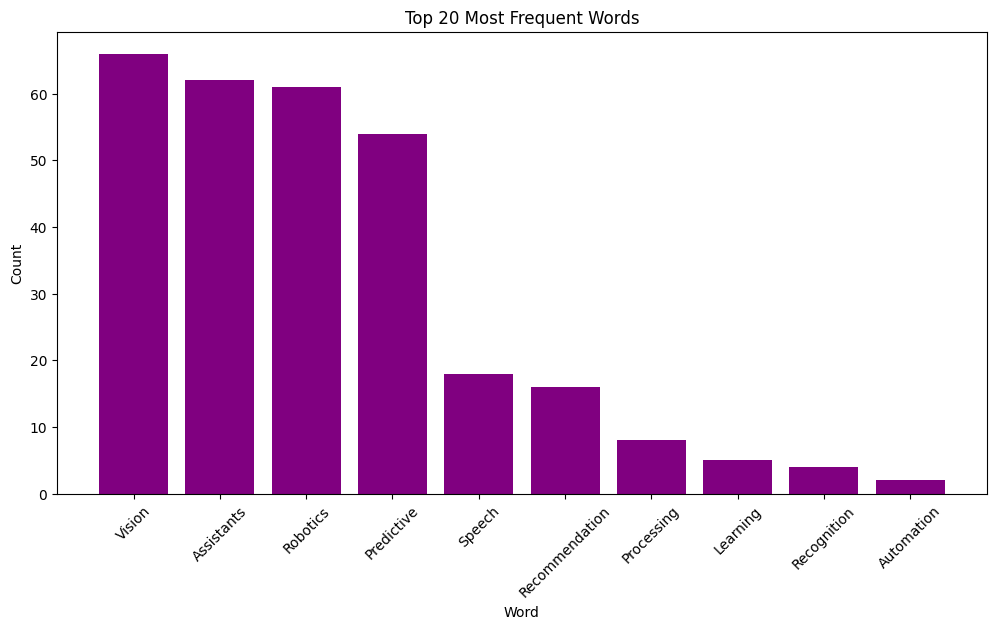

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File /databricks/python/lib/python3.12/site-packages/pandas/core/indexes/base.py:3805, in Index.get_loc(self, key)
   3804 try:
-> 3805     return self._engine.get_loc(casted_key)
   3806 except KeyError as err:

File index.pyx:167, in pandas._libs.index.IndexEngine.get_loc()

File index.pyx:196, in pandas._libs.index.IndexEngine.get_loc()

File pandas/_libs/hashtable_class_helper.pxi:7081, in pandas._libs.hashtable.PyObjectHashTable.get_item()

File pandas/_libs/hashtable_class_helper.pxi:7089, in pandas._libs.hashtable.PyObjectHashTable.get_item()

KeyError: 'value'

The above exception was the direct cause of the following exception:

KeyError                                  Traceback (most recent call last)
File <command-4840430629239592>, line 33
     31 word_count_pd = word_count.toPandas().head(20)
     32 plt.figure(figsize=(12

In [0]:
import matplotlib.pyplot as plt

# Query 1: Count words starting with a vowel or consonant
result_pd = result.toPandas()
plt.figure(figsize=(6,4))
plt.bar(result_pd['first_letter_type'], result_pd['count'], color=['skyblue', 'salmon'])
plt.title('Word Count by First Letter Type')
plt.xlabel('First Letter Type')
plt.ylabel('Count')
plt.show()

# Query 2: Count occurrences of each initial letter (Pie Chart)
initial_letter_count_pd = initial_letter_count.toPandas()
plt.figure(figsize=(8,8))
plt.pie(initial_letter_count_pd['count'], labels=initial_letter_count_pd['first_letter'], autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Word Count by Initial Letter')
plt.show()

# Query 3: Count occurrences of each word length
word_length_count_pd = word_length_count.toPandas()
plt.figure(figsize=(10,5))
colors = plt.cm.tab20.colors[:len(word_length_count_pd)]
plt.bar(word_length_count_pd['word_length'], word_length_count_pd['count'], color=colors)
plt.title('Word Count by Word Length')
plt.xlabel('Word Length')
plt.ylabel('Count')
plt.show()

# Query 4: Count occurrences of each word (top 20), ordered by count descending
word_count_pd = word_count.toPandas().sort_values('count', ascending=False).head(20)
plt.figure(figsize=(12,6))
plt.bar(word_count_pd['word'], word_count_pd['count'], color='purple')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()